<a href="https://colab.research.google.com/github/SuryaSK46/-SOLUTION-TO-A-SYSTEM-OF-LINEAR-EQUATIONS/blob/main/NN_regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [15]:
dataset1 = pd.read_csv('/content/Book1.csv')
X = dataset1[['input']].values
y = dataset1[['output']].values

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [17]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [19]:
# Name:
# Register Number:
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        # Include your code here
        self.fc1 = nn.Linear(1, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
        self.history = {'loss': []} # Initialize history dictionary

  def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [20]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.01)

In [21]:
# Name:
# Register Number:
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = ai_brain(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        ai_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [22]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 12940.635742
Epoch [200/2000], Loss: 6631.428711
Epoch [400/2000], Loss: 1133.087036
Epoch [600/2000], Loss: 795.055298
Epoch [800/2000], Loss: 533.894043
Epoch [1000/2000], Loss: 308.940216
Epoch [1200/2000], Loss: 145.760941
Epoch [1400/2000], Loss: 53.113510
Epoch [1600/2000], Loss: 14.444982
Epoch [1800/2000], Loss: 2.911563


In [23]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 0.525619


In [24]:
loss_df = pd.DataFrame(ai_brain.history)

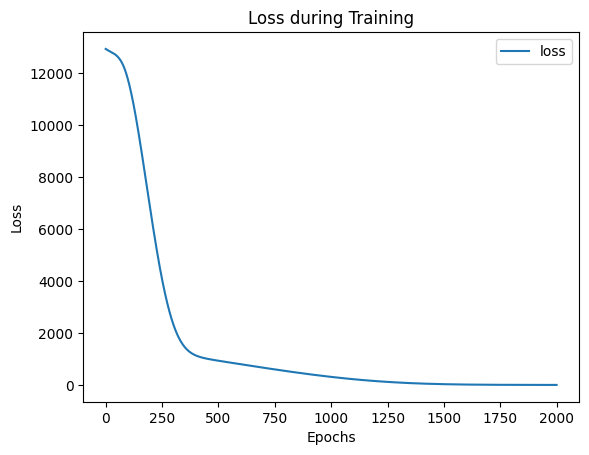

In [25]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [26]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 90.27239990234375


In [27]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 0.438280
Epoch [200/2000], Loss: 0.049488
Epoch [400/2000], Loss: 0.004156
Epoch [600/2000], Loss: 0.000254
Epoch [800/2000], Loss: 0.000011
Epoch [1000/2000], Loss: 0.000000
Epoch [1200/2000], Loss: 0.000000
Epoch [1400/2000], Loss: 0.000000
Epoch [1600/2000], Loss: 0.000000
Epoch [1800/2000], Loss: 0.000000


In [28]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [30]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [31]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 3770981.500000
Epoch [200/2000], Loss: 677.167847
Epoch [400/2000], Loss: 582.074158
Epoch [600/2000], Loss: 492.646912
Epoch [800/2000], Loss: 409.714905
Epoch [1000/2000], Loss: 334.169586
Epoch [1200/2000], Loss: 266.706818
Epoch [1400/2000], Loss: 207.783295
Epoch [1600/2000], Loss: 157.574844
Epoch [1800/2000], Loss: 115.961151
